In [18]:
# Essentially the code from 9
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.api import OLS, add_constant

# Load data
price_data = pd.read_csv("../data/prices.csv", index_col = 0, parse_dates = True).dropna()
price_data.head()
# Estimate β using rolling window
window = 252
rolling_beta = []

for i in range(window, len(price_data)):
    y = price_data["AAPL"].iloc[i-window:i]
    X = add_constant(price_data["MSFT"].iloc[i-window:i])
    model = OLS(y,X).fit()
    rolling_beta.append(model.params["MSFT"])

rolling_beta = pd.Series(rolling_beta, index = price_data.index[window:])

# Calculate rolling spread
aligned_prices = price_data.loc[rolling_beta.index]
spread = alligned_prices["AAPL"] - rolling_beta * aligned_prices["MSFT"]

# Calculate rolling Z-Score
z_window = 60
rolling_mean = spread.rolling(z_window).mean()
rolling_std = spread.rolling(z_window).std()
zscore = (spread - rolling_mean)/ rolling_std

# Create a trading signal based of Z-Score
position = pd.Series(0, index = zscore.index) # a Series with 0s
position[zscore > 2] = -1
position[zscore < -2] = 1
position = position.ffill()

In [22]:
# Adding transaction costs
spread_returns = spread.diff() # calculate bid-ask spread
strategy_returns = position.shift(1) * spread_returns # move values down by 1 to prevent look ahead bias(as info from today can only be acted tommorow)

cost_per_trade = 0.005 
position_change = position.diff().abs() # note that a bigger position change (like -1 -> 1) means higher costs (from formula). We take modulus as direction doesn't matter 

transaction_costs = cost_per_trade * position_change

strategy_returns_net = strategy_returns - transaction_costs
strategy_returns_net = strategy_returns.fillna(0)

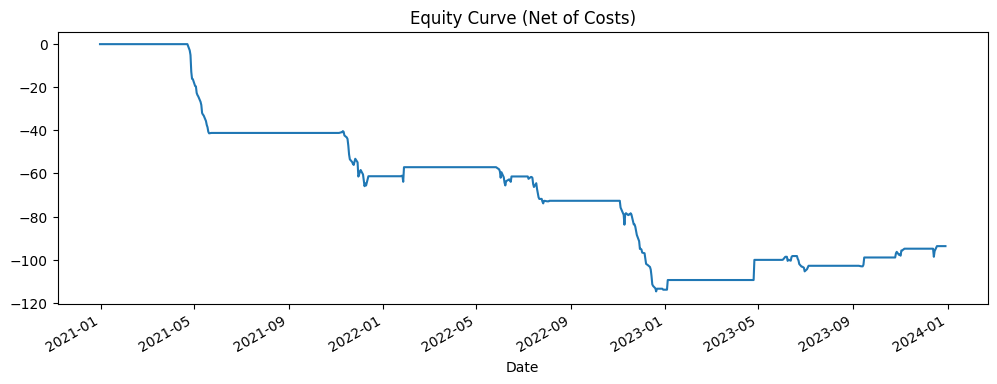

In [24]:
# Plot an equity curve
equity_curve = strategy_returns_net.cumsum()
equity_curve.plot(figsize = (12,4))
plt.title("Equity Curve (Net of Costs)")
plt.show()

# We look for an upward drife, stability and large drawdowns
# If equity collapses after costs, then our strategy was fragile


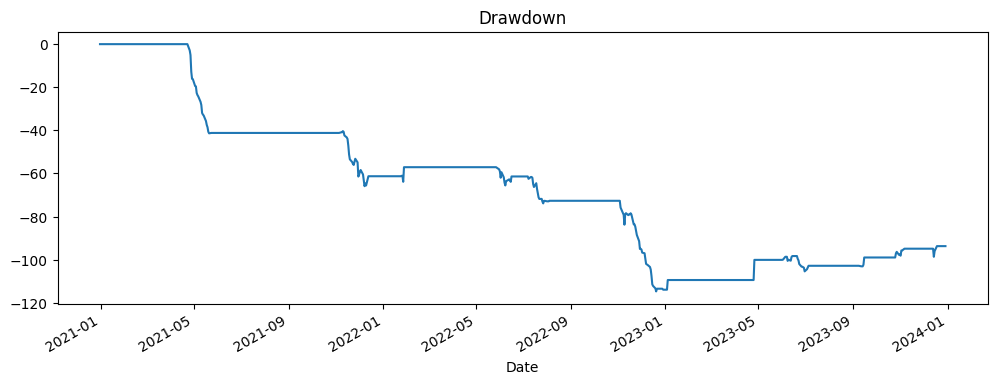

Max Drawdown:  -114.76896471877848


In [27]:
# Using the concept of drawdown as it captures risk better than volatility
rolling_max = equity_curve.cummax()
drawdown = equity_curve - rolling_max # not max - min as it is rolling so we don't know what happens in the future

# Plot the drawdown
drawdown.plot(figsize=(12,4))
plt.title("Drawdown")
plt.show()

max_drawdown = drawdown.min()
print("Max Drawdown: ", max_drawdown)

### A large negative drawdown means:
- The strategy is vulnerable to regime shifts
- Correlation breakdown
- Structural model error

In [30]:
# Compute a Performance Metrics Table

mean_return = strategy_returns_net.mean()
volatility = strategy_returns_net.std() # volatility is just the std of the stock price

annual_return = mean_return * 252
annual_vol = volatility * np.sqrt(252)
sharpe = annual_return / annual_vol

# Using a dictionary/ hashmap then convert to a dataframe: 
performance = pd.DataFrame({
    "Annual Return": [annual_return],
    "Annual Volatility": [annual_vol],
    "Sharpe Ratio" :[sharpe],
    "Max Drawdown": [max_drawdown]
})

performance

,Annual Return,Annual Volatility,Sharpe Ratio,Max Drawdown
0,-31.332376,15.826663,-1.979721,-114.768965
